In [ ]:
# Import 
import pandas as pd

In [2]:
#Load the data 
df = pd.read_parquet('D:\\Projects\\Customer_Retention\\data\\01_cleaned_retail.parquet', engine='pyarrow')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,InvoiceDay,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12


In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"The snapshot date is: {snapshot_date}")

The snapshot date is: 2011-12-10 12:50:00


In [4]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  
    'Invoice': 'nunique',                                     
    'Revenue': 'sum'                                          
}).reset_index()

In [5]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

In [6]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [7]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [8]:
rfm = rfm[rfm['Monetary'] > 0]

print(f"Number of valid customers: {len(rfm)}")

Number of valid customers: 5878


<Axes: title={'center': 'Distribution of Monetary Value'}, ylabel='Frequency'>

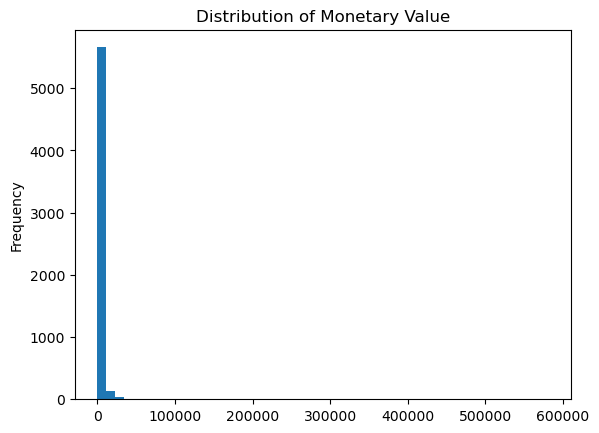

In [9]:
# Plot the distribution of the Monetary column
rfm['Monetary'].plot(kind='hist', bins=50, title='Distribution of Monetary Value')

In [10]:
# Sociring R, F, M 
r_labels = range(5, 0, -1)
f_labels = range(1, 6)
m_labels = range(1, 6)

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

In [11]:
# Creating a customer segments 
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

def assign_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Needs Attention'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost / Hibernating'

In [12]:
rfm['Segment_Label'] = rfm['RFM_Score'].apply(assign_segment)

In [13]:
final_cols = ['Customer ID', 'Recency', 'Frequency', 'Monetary', 
              'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'RFM_Score', 'Segment_Label']

rfm_final = rfm[final_cols]

In [14]:
rfm_final.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment_Label
0,12346,326,12,77556.46,2,5,5,255,12,Loyal Customers
1,12347,2,8,4921.53,5,4,5,545,14,Champions
2,12348,75,5,2019.40,3,4,4,344,11,Loyal Customers
3,12349,19,4,4428.69,5,3,5,535,13,Champions
4,12350,310,1,334.40,2,1,2,212,5,At Risk
5,12351,375,1,300.93,2,1,2,212,5,At Risk
6,12352,36,10,2849.84,4,5,4,454,13,Champions
7,12353,204,2,406.76,2,2,2,222,6,At Risk
8,12354,232,1,1079.40,2,1,3,213,6,At Risk
9,12355,214,2,947.61,2,2,3,223,7,Needs Attention


In [15]:

output_path_parquet = 'D:\\Projects\\Customer_Retention\\data\\02_rfm_features.parquet'

rfm_final.to_parquet(output_path_parquet, engine='pyarrow', index=False)

print("Data framed saved")

Data framed saved
